# Module 1 | Part 1: Introduction to PyRIT & Setup
## AI Security Testing with PyRIT — From Zero to Red Team

---

Welcome to the PyRIT course! This is Module 1, Part 1.

> **No attacks in this notebook.** This is all about understanding the tool and getting your environment ready.

---

## 1. What is AI Red-Teaming?

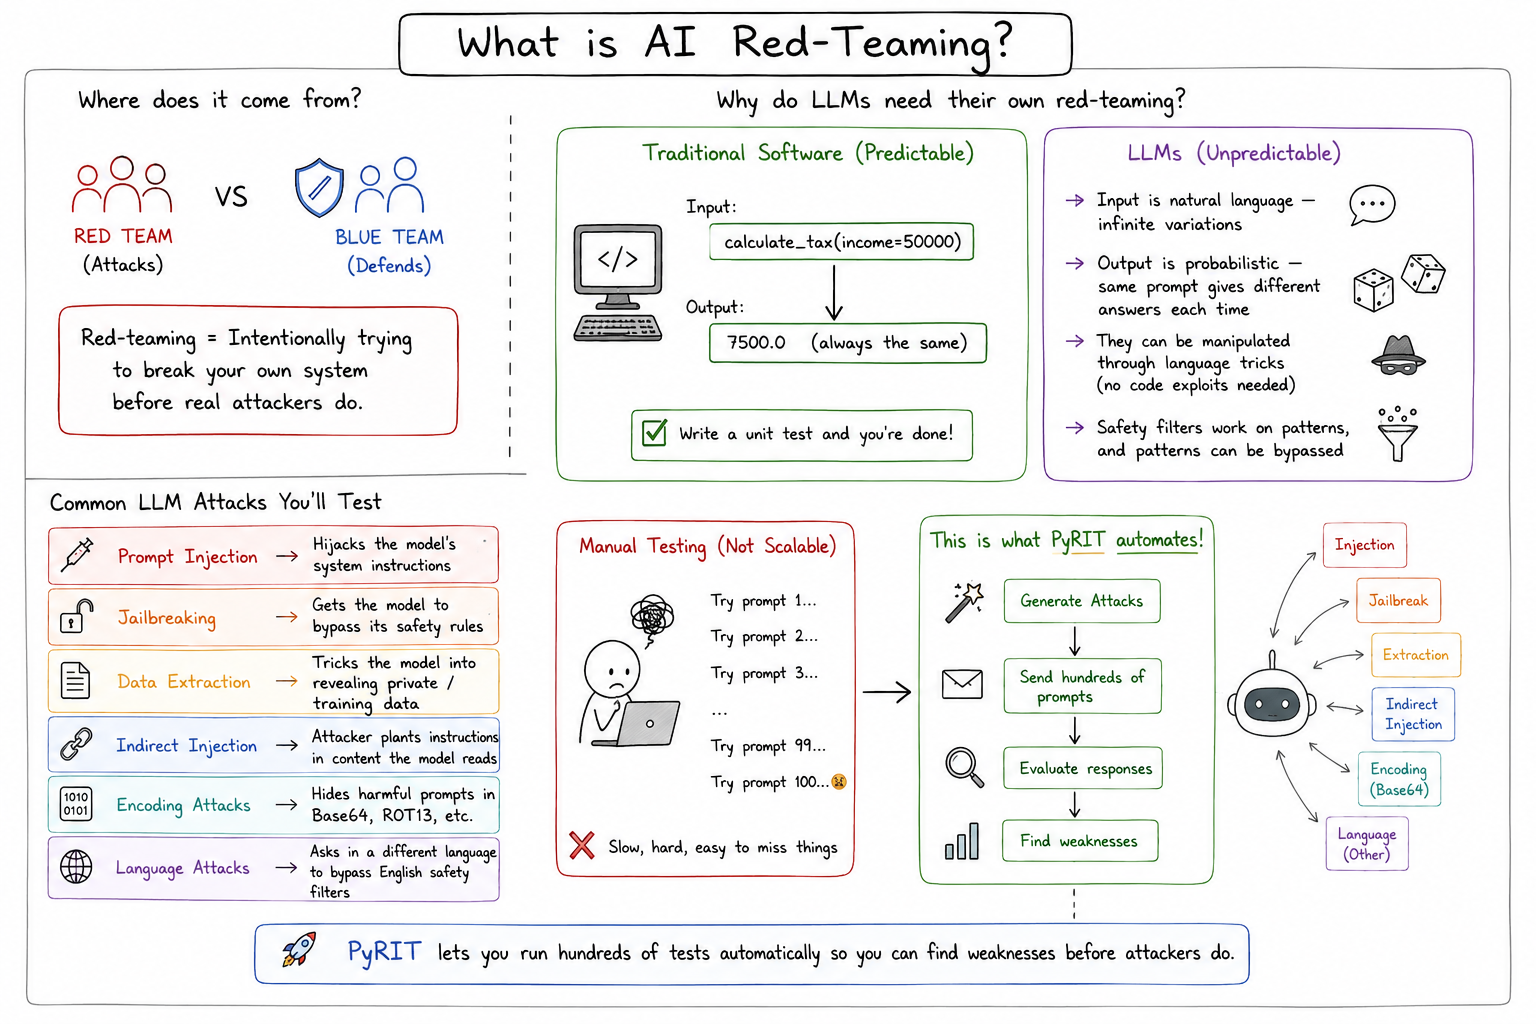

## 2. What is PyRIT?

**PyRIT** = **Py**thon **R**isk **I**dentification **T**oolkit

Built by **Microsoft** and released as open source in 2024. It is the industry-standard toolkit for:
- Automated red-teaming of LLMs and AI agents
- Testing AI systems for safety and security vulnerabilities
- Scaling manual red-teaming with automation

### Key facts:
- **GitHub**: `microsoft/pyrit`
- **Language**: Python
- **Works with**: OpenAI, Groq, Azure OpenAI, any HTTP API
- **Storage**: SQLite (a local, file-based database — no cloud needed)
- **License**: MIT (free and open source)

### Think of PyRIT like this:

> PyRIT is to AI security what **pytest** is to unit testing.

Without PyRIT, an AI security tester manually writes prompts, sends them one by one, reads each response, and takes notes. That doesn't scale.

With PyRIT, you write a test **once** and run it against thousands of prompts automatically, with automatic scoring.

## 3. PyRIT Architecture: The 5 Building Blocks

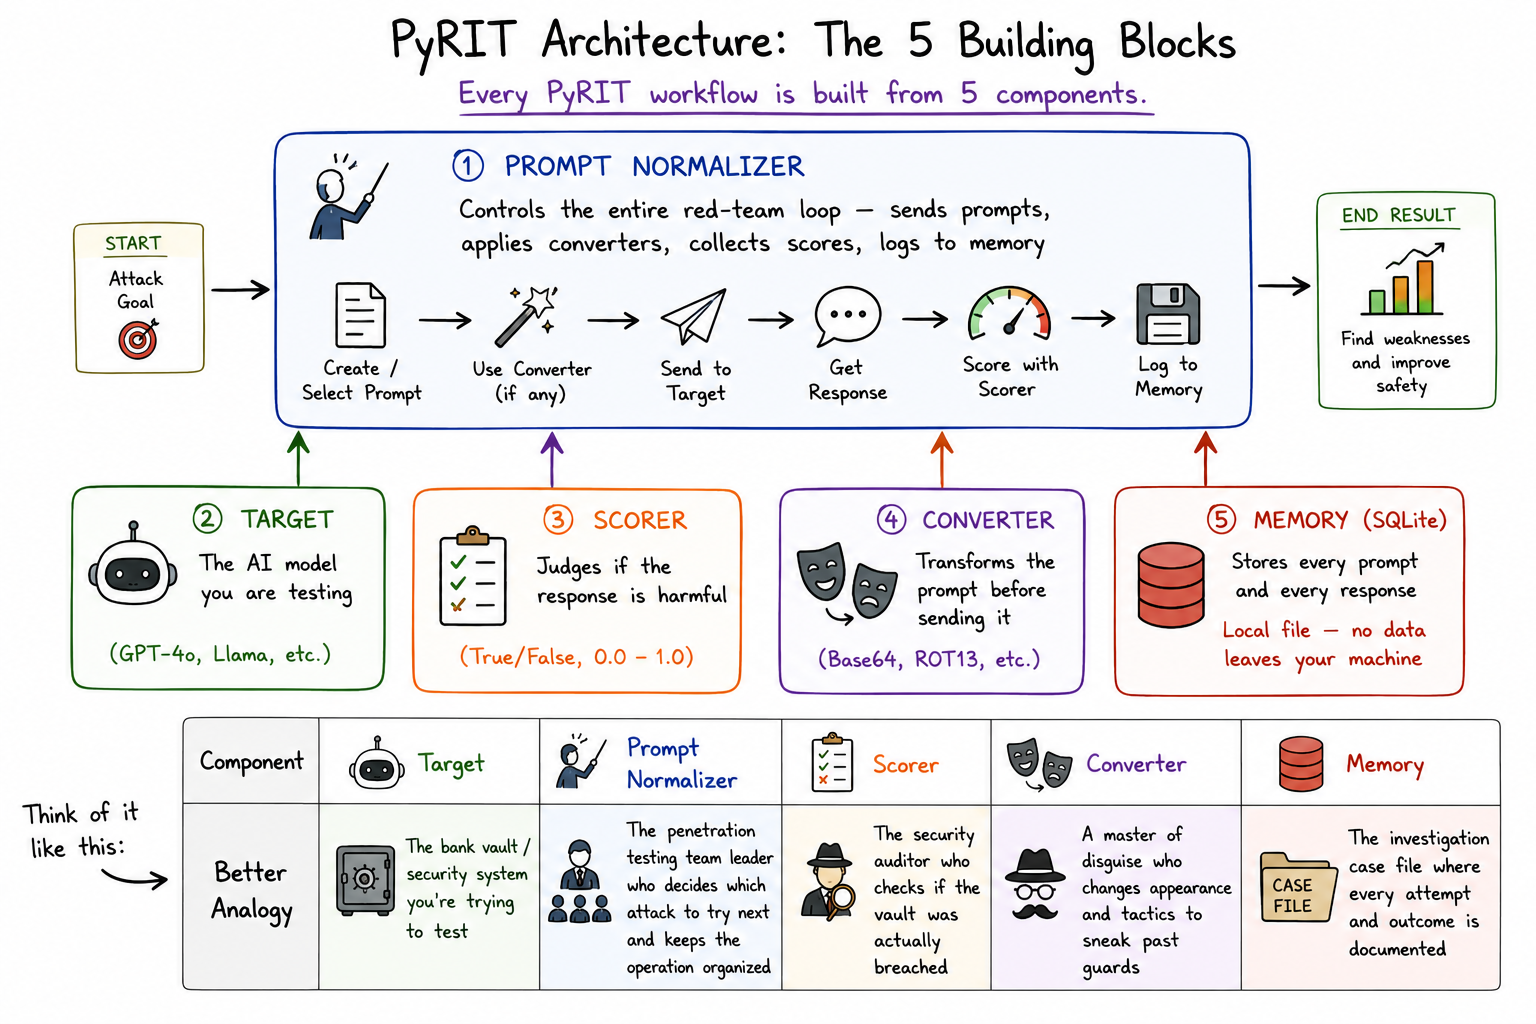

> We will explore each of these deeply in Part 2. For now, just know these 5 words.

## 4. Installation

### Option A: pip (recommended for this course)

```bash
pip install pyrit
```

### Option B: Conda environment (cleaner isolation)

```bash
conda create -n pyrit-env python=3.10
conda activate pyrit-env
pip install pyrit
```

### Requirements:
- Python 3.10 or higher
- ~500 MB disk space
- Internet connection (for API calls to OpenAI/Groq)

Run the cell below to install:

In [2]:
# Install PyRIT and supporting packages
!pip install pyrit -q
!pip install python-dotenv -q
!pip install nest_asyncio -q

print("Installation complete!")


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Installation complete!



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Verify the installation — PyRIT 0.14+ compatible
import importlib.metadata
print(f"PyRIT version: {importlib.metadata.version('pyrit')}")

from pyrit.prompt_target import OpenAIChatTarget
from pyrit.prompt_normalizer import PromptNormalizer
from pyrit.memory import SQLiteMemory, CentralMemory
from pyrit.models import Message, MessagePiece
from pyrit.score import SelfAskTrueFalseScorer, TrueFalseQuestion
from pyrit.prompt_converter import Base64Converter

print("All core modules imported successfully!")

PyRIT version: 0.14.0
All core modules imported successfully!


## 5. Setting Up API Keys

We will use two LLM providers in this course:

| Provider | Models | Get your key at |
|---------|--------|----------------|
| **OpenAI** | GPT-4o-mini, GPT-4o | https://platform.openai.com |
| **Groq** | Llama 3.1, Mixtral, Gemma | https://console.groq.com |

### Best practice: Use a `.env` file

NEVER hardcode API keys in your notebook code. Use a `.env` file:

**Step 1:** Create a file named `.env` in the same folder as this notebook

**Step 2:** Add your keys:
```
OPENAI_API_KEY=sk-your-openai-key-here
GROQ_API_KEY=gsk_your-groq-key-here
```

**Step 3:** Load them with `python-dotenv` (shown in the next cell)

> **Security tip:** Add `.env` to your `.gitignore` file. Never commit API keys to GitHub!

In [4]:
from pathlib import Path

# Create a .env template file (run this once)
env_path = Path(".env")

if not env_path.exists():
    template = """# PyRIT Course - API Keys
# Replace the placeholder values below with your actual API keys

OPENAI_API_KEY=sk-your-openai-key-here
GROQ_API_KEY=gsk_your-groq-key-here
"""
    env_path.write_text(template)
    print(".env template created!")
    print("ACTION NEEDED: Open the .env file and add your actual API keys")
else:
    print(".env file already exists")

.env file already exists


In [5]:
from dotenv import load_dotenv
import os

load_dotenv()

openai_key = os.getenv("OPENAI_API_KEY", "NOT SET")
groq_key   = os.getenv("GROQ_API_KEY",   "NOT SET")

def mask_key(key: str) -> str:
    if key in ("NOT SET", "") or len(key) < 8:
        return key
    return key[:7] + "..." + key[-4:]

print(f"OpenAI API Key : {mask_key(openai_key)}")
print(f"Groq API Key   : {mask_key(groq_key)}")

if openai_key in ("NOT SET", "sk-your-openai-key-here"):
    print("\nWARNING: OpenAI key not set. Add it to your .env file.")
else:
    print("\nAPI keys loaded successfully!")

OpenAI API Key : sk-proj...s2UA
Groq API Key   : gsk_AgB...AlNY

API keys loaded successfully!


## 6. PyRIT Memory: SQLite

Before sending any prompts, we need to set up **memory**.

### What is SQLite?

SQLite is a fast, lightweight database that runs as a single file on your computer — no server needed.

PyRIT 0.14 uses **SQLiteMemory** as its default local storage backend.

### Why does PyRIT need memory?

PyRIT stores **every single prompt and response** automatically. This is central to everything:

| What gets stored | Why it matters |
|-----------------|---------------|
| Every prompt you send | Reproducibility — replay any experiment |
| Every response received | Analyze patterns across hundreds of tests |
| Conversation history | Multi-turn attacks need context |
| Scores from scorers | Know which prompts triggered failures |
| Converter metadata | Track what transformations were applied |

The database file is created locally in your PyRIT data directory. You never need to write SQL — PyRIT has Python methods for everything.

In [6]:
import nest_asyncio
from pyrit.memory import SQLiteMemory, CentralMemory

# Required to use async/await in Jupyter notebooks
nest_asyncio.apply()

# Create a SQLiteMemory instance (local file-based database)
memory = SQLiteMemory()

# Tell PyRIT to use this as the global memory store
CentralMemory.set_memory_instance(memory)

print("Memory initialized")
print(f"Memory type : {type(memory).__name__}")

# Check how many entries are already stored
existing = memory.get_message_pieces()
print(f"Existing records: {len(existing)}")

[pyrit:alembic] No new upgrade operations detected.
Memory initialized
Memory type : SQLiteMemory
Existing records: 879


## 7. Your First PyRIT Target: OpenAI

A **Target** represents the AI model you want to test.

`OpenAIChatTarget` is PyRIT's adapter for:
- **OpenAI's API** (GPT-4o, GPT-4o-mini, GPT-3.5-turbo, etc.)
- **Any OpenAI-compatible API** (Groq, Together AI, etc.)

Key constructor parameters in PyRIT 0.14:

| Parameter | What it does | Example |
|-----------|-------------|--------|
| `model_name` | The model to use | `"gpt-4o-mini"` |
| `endpoint` | The API URL | `"https://api.openai.com/v1"` |
| `api_key` | Your API key | `os.environ["OPENAI_API_KEY"]` |

> **Note:** In PyRIT 0.14, the parameter is `model_name` (not `deployment_name` from older versions).

The **PromptNormalizer** manages sending — you give it a `Message` and a `Target`, it handles the rest.

In [7]:
import os
from pyrit.prompt_target import OpenAIChatTarget
from pyrit.prompt_normalizer import PromptNormalizer
from pyrit.models import Message, MessagePiece

# Create the OpenAI target (PyRIT 0.14: use model_name, not deployment_name)
openai_target = OpenAIChatTarget(
    model_name="gpt-4o-mini",
    endpoint="https://api.openai.com/v1",
    api_key=os.environ["OPENAI_API_KEY"]
)

print("OpenAI target created!")
print(f"  Model    : gpt-4o-mini")
print(f"  Endpoint : https://api.openai.com/v1")
print()

# PromptNormalizer replaces PromptSendingOrchestrator in PyRIT 0.14
# It auto-connects to the CentralMemory instance we set up above
normalizer = PromptNormalizer()

# Build the message — wraps the prompt text in a MessagePiece
msg = Message(message_pieces=[
    MessagePiece(role="user", original_value="What is artificial intelligence? Answer in exactly 2 sentences.")
])

print("Sending first prompt via PyRIT PromptNormalizer...")
print("-" * 50)

# send_prompt_async sends ONE message to ONE target and returns a Message response
response = await normalizer.send_prompt_async(message=msg, target=openai_target)

print("Response received!")
print("-" * 50)
for piece in response.message_pieces:
    if piece.role == "assistant":
        print(piece.original_value)

OpenAI target created!
  Model    : gpt-4o-mini
  Endpoint : https://api.openai.com/v1

Sending first prompt via PyRIT PromptNormalizer...
--------------------------------------------------
Response received!
--------------------------------------------------
Artificial intelligence (AI) refers to the simulation of human intelligence in machines designed to think and learn like humans. It encompasses a range of technologies, including machine learning, natural language processing, and robotics, aiming to perform tasks that typically require human cognitive functions.


## 8. Understanding the Response Object

The response you got back is a **`Message`** object containing a list of **`MessagePiece`** objects.

Each `MessagePiece` contains:
- `role` — who sent this piece: `"user"` or `"assistant"`
- `original_value` — the raw text content
- `converted_value` — text after any converters were applied
- `original_value_data_type` — `"text"`, `"image"`, `"audio"`, etc.
- `conversation_id` — unique ID linking all turns in a conversation
- `timestamp` — when it was sent/received

All of this is automatically saved to SQLite memory for later analysis.

In [8]:
# Inspect the response object in detail
print("=== Response Object Internals ===")
print()
print(f"Response type       : {type(response).__name__}")
print(f"Number of pieces    : {len(response.message_pieces)}")
print()

for i, piece in enumerate(response.message_pieces):
    print(f"  --- MessagePiece #{i+1} ---")
    print(f"  role                    : {piece.role}")
    print(f"  original_value          : {str(piece.original_value)[:120]}")
    print(f"  original_value_data_type: {piece.original_value_data_type}")
    print(f"  conversation_id         : {piece.conversation_id}")
    print(f"  timestamp               : {piece.timestamp}")
    print()

=== Response Object Internals ===

Response type       : Message
Number of pieces    : 1

  --- MessagePiece #1 ---
  role                    : assistant
  original_value          : Artificial intelligence (AI) refers to the simulation of human intelligence in machines designed to think and learn like
  original_value_data_type: text
  conversation_id         : c6d3ab84-feb4-45a4-bfdc-41053fa96890
  timestamp               : 2026-06-18 05:33:33.586393+00:00



## 9. Using Groq as a Target

**Groq** provides extremely fast inference for open-source models.

Models available on Groq (as of 2025):

| Model ID | Description |
|---------|-------------|
| `llama-3.1-8b-instant` | Fast and light — great for testing |
| `llama-3.1-70b-versatile` | More capable, still fast |
| `mixtral-8x7b-32768` | Mixtral model, 32k context |
| `gemma2-9b-it` | Google Gemma 2 |

### The key insight:

Groq's API is **100% compatible with the OpenAI API format**.

This means we use the exact same `OpenAIChatTarget` class for Groq — just change two things:
1. The `endpoint` URL → Groq's URL
2. The `api_key` → Your Groq key

In [9]:
# Same class — OpenAIChatTarget — just different endpoint and key
groq_target = OpenAIChatTarget(
    model_name="llama-3.1-8b-instant",
    endpoint="https://api.groq.com/openai/v1",
    api_key=os.environ["GROQ_API_KEY"]
)

print("Groq target created!")
print(f"  Model    : llama-3.1-8b-instant")
print(f"  Endpoint : https://api.groq.com/openai/v1")
print()

groq_normalizer = PromptNormalizer()

groq_msg = Message(message_pieces=[
    MessagePiece(role="user", original_value="What is artificial intelligence? Answer in exactly 2 sentences.")
])

print("Sending prompt to Groq (Llama 3.1 8B)...")
print("-" * 50)

groq_response = await groq_normalizer.send_prompt_async(message=groq_msg, target=groq_target)

print("Response received from Groq!")
print("-" * 50)
for piece in groq_response.message_pieces:
    if piece.role == "assistant":
        print(piece.original_value)

Groq target created!
  Model    : llama-3.1-8b-instant
  Endpoint : https://api.groq.com/openai/v1

Sending prompt to Groq (Llama 3.1 8B)...
--------------------------------------------------
Response received from Groq!
--------------------------------------------------
Artificial intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, decision-making, and perception, through the use of algorithms and data processing. AI systems can be trained on large amounts of data to analyze patterns, recognize objects, and make predictions, allowing them to adapt and improve their performance over time.


## 10. Checking Memory: Everything is Logged

We have sent 2 conversations so far (one to OpenAI, one to Groq).

PyRIT automatically logged all of them to SQLite memory. Let us query what got stored.

In [10]:
from pyrit.memory import CentralMemory

# Get the memory instance we set up earlier
memory = CentralMemory.get_memory_instance()

# get_message_pieces() is the PyRIT 0.14 query method
all_pieces = memory.get_message_pieces()

print("=== SQLite Memory Contents ===")
print(f"Total stored message pieces: {len(all_pieces)}")

# Count unique conversations
conv_ids = list(set(p.conversation_id for p in all_pieces))
print(f"Total conversations        : {len(conv_ids)}")

# Count by role
user_msgs = [p for p in all_pieces if p.role == "user"]
bot_msgs  = [p for p in all_pieces if p.role == "assistant"]
print(f"User messages              : {len(user_msgs)}")
print(f"Assistant messages         : {len(bot_msgs)}")
print()
print("Last 4 stored pieces:")
print("-" * 60)

for piece in all_pieces[-4:]:
    icon = "You ->" if piece.role == "user" else "AI  ->"
    text = str(piece.original_value)[:80].replace("\n", " ")
    print(f"{icon} {text}")
    print(f"       conversation_id: {piece.conversation_id[:16]}...")
    print()

=== SQLite Memory Contents ===
Total stored message pieces: 883
Total conversations        : 507
User messages              : 296
Assistant messages         : 298

Last 4 stored pieces:
------------------------------------------------------------
You -> What is artificial intelligence? Answer in exactly 2 sentences.
       conversation_id: c6d3ab84-feb4-45...

AI  -> Artificial intelligence (AI) refers to the simulation of human intelligence in m
       conversation_id: c6d3ab84-feb4-45...

You -> What is artificial intelligence? Answer in exactly 2 sentences.
       conversation_id: 93908baa-3a73-44...

AI  -> Artificial intelligence (AI) refers to the development of computer systems that 
       conversation_id: 93908baa-3a73-44...

